# NIST PQC Competition

Post-Quantum Cryptography Standardization is a program and competition by NIST to update their standards to include post-quantum cryptography. 
Twenty-three signature schemes and fifty-nine encryption/KEM schemes (for 82 schemes in total) were submitted by the initial submission deadline

- For more details about each round visit [wikipedia](https://en.wikipedia.org/wiki/NIST_Post-Quantum_Cryptography_Standardization).  
- Below a timeline that breafly recall the NIST PQC competition

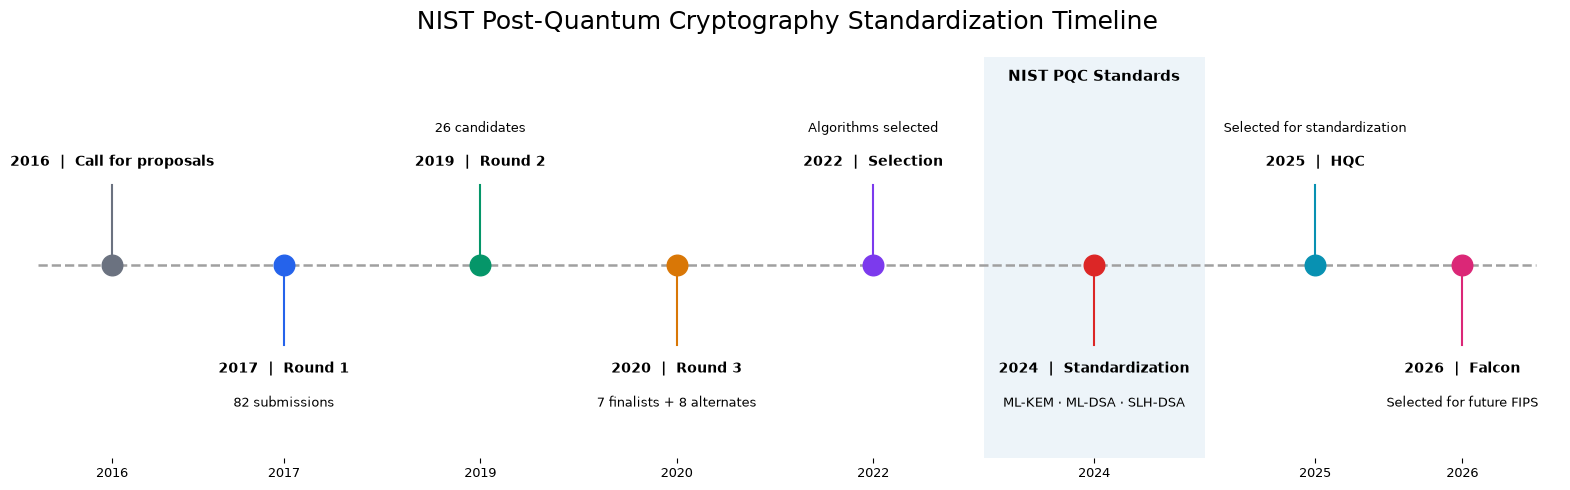

In [1]:
from nist_pqc import draw_timeline
draw_timeline();

## Standard pubblicati

La tabella seguente riassume le principali caratteristiche degli schemi standardizzati e di quelli selezionati per la standardizzazione.

| Schema | FIPS | Famiglia | Tipologia | Security model | Specs |
|---|---|---|---|---|---|
| **ML-KEM** | FIPS 203 [[1]](https://csrc.nist.gov/pubs/fips/203/final)| Lattice-based | KEM | `IND-CCA2` |  [[4]](https://pq-crystals.org/kyber/)
| **ML-DSA** | FIPS 204 [[2]](https://csrc.nist.gov/pubs/fips/204/final)| Lattice-based | DSS | `SUF-CMA` | [[5]](https://pq-crystals.org/dilithium/)|
| **SLH-DSA** | FIPS 205 [[3]](https://csrc.nist.gov/pubs/fips/204/final)| Hash-based | DSS | `SUF-CMA` | |
| **HQC** | — | Code-based | KEM | `IND-CCA2` | [[6]](https://pqc-hqc.org/)|
| **FN-DSA** | — | Lattice-based | DSS | `SUF-CMA` | [[7]](https://falcon-sign.info) |

La comparison tra tutti gli schemi in gara NIST e' disponibile:

- per le [DSS](https://pqshield.github.io/nist-sigs-zoo/)
- per i [KEM](https://pqshield.github.io/nist-sigs-zoo/kems/)


# Implementazione

Per poter utilizzare concretamente questi algoritmi è però necessario implementare le operazioni matematiche su una piattaforma hardware reale.

Gli algoritmi PQC lavorano spesso con vettori, matrici e polinomi di grandi dimensioni. L'efficienza dell'implementazione è quindi un aspetto fondamentale, ma bisogna inoltre tenere conto dell'architettura hardware sulla quale vengono eseguite. Tra le architetture più comuni troviamo:

- `x86_64` / `amd64`
- `aarch64` / `ARM64`

Una stessa primitiva può quindi avere una implementazione portabile, che funziona su diverse architetture, e implementazioni ottimizzate per una specifica piattaforma.



## Ottimizzazioni Software

I processori moderni mettono a disposizione istruzioni specifiche che permettono di eseguire più operazioni contemporaneamente.
Una delle tecniche principali è il SIMD (Single Instruction, Multiple Data).

Gli oggetti matematici con cui ci troviamo a lavorare come abbiamo visto sono matrici e vettori di grandi dimensioni quindi vanno implmentate in maniera molto efficente. 


```
              Implementation
                     │
          ┌──────────┼──────────┐
          │          │          │
       portable    x86_64      ARM
          │          │          │
          │       AVX2/...   Neon/...
          │          │
          └──────────┴──────────┘
                     │
                     ▼
                  Hardware
```




## Hardware Dedicato

È possibile spingersi oltre l'ottimizzazione software utilizzando hardware dedicato, ad esempio FPGA o ASIC.
In questo caso alcune operazioni crittografiche vengono implementate direttamente nell'hardware, permettendo di ottimizzare:

- throughput;
- latenza;
- consumo energetico;
- utilizzo delle risorse.



## Panoramica

Possiamo quindi pensare a diversi livelli di implementazione:

```
                  Algoritmo PQC
                       │
                       ▼
                 Implementazione
                       │
          ┌────────────┴────────────┐
          │                         │
       Software                  Hardware
          │                         │
    ┌─────┴─────┐             ┌─────┴─────┐
    │           │             │           │
 Portable   Optimized       FPGA        ASIC
            SIMD/ASM
```

La tabella contiene anche le repository delle implementazioni:


| Schema | FIPS | Famiglia | Tipologia | Security model | Specs | Repository |
|---|---|---|---|---|---|---|
| **ML-KEM** | FIPS 203 [[1]](https://csrc.nist.gov/pubs/fips/203/final)| Lattice-based | KEM | `IND-CCA2` |  [[4]](https://pq-crystals.org/kyber/) | [[repo]](https://github.com/pq-code-package/mlkem-native) |
| **ML-DSA** | FIPS 204 [[2]](https://csrc.nist.gov/pubs/fips/204/final)| Lattice-based | DSS | `SUF-CMA` | [[5]](https://pq-crystals.org/dilithium/)| [[repo]](https://github.com/pq-code-package/mldsa-native) |
| **SLH-DSA** | FIPS 205 [[3]](https://csrc.nist.gov/pubs/fips/204/final)| Hash-based | DSS | `SUF-CMA` | | [[repo]](https://github.com/pq-code-package/slhdsa-c/)|
| **HQC** | — | Code-based | KEM | `IND-CCA2` | [[6]](https://pqc-hqc.org/)| [[repo]](https://gitlab.com/pqc-hqc) |
| **FN-DSA** | — | Lattice-based | DSS | `SUF-CMA` | [[7]](https://falcon-sign.info) | [[repo]](https://github.com/PQClean/PQClean)|



# Openquantumsafe

Il numero di algoritmi, implementazioni e ottimizzazioni disponibili rende però poco pratico interagire direttamente con ogni singola implementazione.
Una soluzione è utilizzare Open Quantum Safe (OQS), un progetto che fornisce un'implementazione software delle principali primitive post-quantum attraverso un'interfaccia comune.

In particolare, liboqs permette di accedere alle primitive PQC senza dover gestire direttamente le diverse implementazioni specifiche di ogni algoritmo.